In [1]:
import pandas as pd
import numpy as np
import os
import pickle
from pyts.image import GramianAngularField
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm
from PIL import Image
from sklearn.linear_model import LinearRegression
import torch
from torchmetrics.image.ssim import StructuralSimilarityIndexMeasure
seq_len_list = [60] #[20, 60]
symbol_list = ['GOOG'] #, 'AAPL',  'AMZN'
database_list = ['only'] #['only', 'industry', 'all']
for seq_len in seq_len_list:
  for symbol in symbol_list:
    for database in database_list:
      total_len = 2 * seq_len  # Total length of the sequence
      if database == 'only' or database == 'industry':
          input_file = f'/home/user11/thongt/Diffusion-TS-all-stock/data_new/{symbol}_{database}_1.csv'
      if database == 'all':
          input_file = f'/home/user11/thongt/Diffusion-TS-all-stock/data_new/all_1.csv'
    
        
      output_dir = f'/home/user11/thongt/ImagenTime_New_flow_3_Backup_2_shuffle/TS2IMG_UNET_1/{symbol}/{symbol}_{database}_gasf_gadf_linear_trend/{seq_len}'
      os.makedirs(output_dir, exist_ok=True)

      df = pd.read_csv(input_file, usecols=['Date', 'Symbol', 'Close'])
      df['Date'] = pd.to_datetime(df['Date'])
      df = df.sort_values(['Symbol', 'Date']) 

      df['Close'] = df['Close'].astype(float)
      all_sequences = []

      def compute_linear_trend(window):
          x = np.arange(len(window)).reshape(-1, 1)
          y = window.reshape(-1, 1)
          
          model = LinearRegression()
          model.fit(x, y)
          trend = model.predict(x).flatten()
          return trend

      for symbol in tqdm(df['Symbol'].unique(), desc="Xử lý symbol"):
          print("Hello")
          df_symbol = df[df['Symbol'] == symbol].copy()
          close_prices = df_symbol['Close'].values
          if len(close_prices) < total_len:
              continue 

          #scaler = MinMaxScaler(feature_range=(-1, 1))
          normalized = close_prices.copy()

          # GAF
          gasf = GramianAngularField(image_size=seq_len, method='summation')
          gadf = GramianAngularField(image_size=seq_len, method='difference')
          tensor_images = []
          window_list = []
            
          for i in range(len(normalized) - total_len + 1):
              window = normalized[i:i + seq_len].reshape(1, -1)
              window_list.append(normalized[i:i + 2 * seq_len].reshape(1, -1))

              # Generate GAF images
              gasf_img = gasf.transform(window)[0]
              gadf_img = gadf.transform(window)[0]
              zeros_img = np.zeros_like(gadf_img)
              trend = compute_linear_trend(window.flatten()).reshape(seq_len, 1)
              trend_img = np.tile(trend, (1, seq_len))
          
              stacked = np.stack([gasf_img, gadf_img, trend_img], axis=-1)
              #stacked = np.stack([gasf_img, gadf_img, zeros_img], axis=-1)
                
              stacked_scaled = ((stacked - np.min(stacked)) / (np.max(stacked) - np.min(stacked)) * 255).astype(np.uint8)
              tensor_img = torch.tensor(stacked_scaled.transpose(2, 0, 1), dtype=torch.float32)
              tensor_images.append(tensor_img)
            
              
              
          batch_tensor = torch.stack(tensor_images, dim=0)
          
          top_k = 10
          margin = 60
          N = len(batch_tensor)
          print(N)
          # split train and test
          split = int(0.7 * N)
        
          all_topk_windows = []
          for i in range(N):
            valid_indices = [j for j in range(N) if abs(j - i) > margin and j <= split]
            if len(valid_indices) < top_k:
                continue
            ref_tensor = batch_tensor[i].unsqueeze(0).repeat(len(valid_indices), 1, 1, 1)
            cmp_tensor = batch_tensor[valid_indices]
            metric = StructuralSimilarityIndexMeasure(data_range=1.0, reduction=None)
            metric.update(ref_tensor, cmp_tensor)
            ssim_scores = metric.compute()
          
            top_scores, top_indices = torch.topk(ssim_scores, k=top_k)
            selected_windows = [window_list[valid_indices[j]] for j in top_indices]
            
            for win in selected_windows:
                all_topk_windows.append(win.flatten())
          concat_tensor = torch.tensor(np.stack(all_topk_windows), dtype=torch.float32).flatten()
          print(concat_tensor.shape)
          output_file = f'/home/user11/thongt/ImagenTime_New_flow_3_Backup_2_shuffle/topk_10_concat_1d_gasf_gadf_linear_trend_scaled.pt'
             
    
          os.makedirs(os.path.dirname(output_file), exist_ok=True)
          torch.save(concat_tensor, output_file)
      print("OK")


Xử lý symbol:   0%|          | 0/1 [00:00<?, ?it/s]

Hello
1139


Xử lý symbol: 100%|██████████| 1/1 [07:10<00:00, 430.23s/it]

torch.Size([1366800])
OK


In [5]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import torch.nn.functional as F

# Load pre-trained VGG16
vgg16 = models.vgg16(pretrained=True)

# Lấy phần features (bỏ FC)
feature_extractor = vgg16.features
feature_extractor.eval()  # Chuyển sang chế độ eval

# Chuẩn bị ảnh đầu vào (vẫn nên normalize)
transform = transforms.Compose([
    transforms.Resize((32, 32)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

# Đọc ảnh
def extract_embedding(img_path):
    img = Image.open(img_path).convert("RGB")
    tensor = transform(img).unsqueeze(0)  # (1, 3, H, W)
    with torch.no_grad():
        feat = feature_extractor(tensor)   # (1, 512, 1, 1)
        return feat.view(1, -1)            # (1, 512)

# Đường dẫn 2 ảnh
img1_path = "thongt/ImagenTime_New_flow_3_Backup_2_shuffle/TS2IMG_UNET/GOOG/GOOG_only_gasf_gadf_linear_trend/60/GOOG_20131003.png"
img2_path = "thongt/ImagenTime_New_flow_3_Backup_2_shuffle/TS2IMG_UNET/GOOG/GOOG_only_gasf_gadf_linear_trend/60/GOOG_20131003.png"
img3_path = "thongt/ImagenTime_New_flow_3_Backup_2_shuffle/TS2IMG_UNET/GOOG/GOOG_only_gasf_gadf_linear_trend/60/GOOG_20141004.png"

# Trích xuất embedding
emb1 = extract_embedding(img1_path)
emb2 = extract_embedding(img2_path)
emb3 = extract_embedding(img3_path)

# Tính cosine similarity
similarity_12 = F.cosine_similarity(emb1, emb2).item()
similarity_13 = F.cosine_similarity(emb1, emb3).item()
similarity_23 = F.cosine_similarity(emb3, emb2).item()

print(f"Similarity score: {similarity_12:.4f}, {similarity_13:.4f}, {similarity_23:.4f}")

FileNotFoundError: [Errno 2] No such file or directory: 'thongt/ImagenTime_New_flow_3_Backup_2_shuffle/TS2IMG_UNET/GOOG/GOOG_only_gasf_gadf_linear_trend/60/GOOG_20131003.png'

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image

# 1. Load pretrained ResNet18 và bỏ lớp FC cuối
resnet18 = models.resnet18(pretrained=True)
resnet18.eval()
feature_extractor = nn.Sequential(*list(resnet18.children())[:-1])  # bỏ FC, giữ đến avgpool

# 2. Transform phù hợp
transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406],
    #                      std =[0.229, 0.224, 0.225])
])

# 3. Hàm trích xuất embedding từ ảnh
def extract_embedding(img_path):
    img = Image.open(img_path).convert("RGB")
    tensor = transform(img).unsqueeze(0)  # (1, 3, H, W)
    with torch.no_grad():
        feat = feature_extractor(tensor)  # (1, 512, 1, 1)
        return feat.view(1, -1)           # (1, 512)

img1_path = "thongt/ImagenTime_New_flow_3_Backup_2_shuffle/TS2IMG_UNET/GOOG/GOOG_only_gasf_gadf_linear_trend/20/GOOG_20121002.png"
img2_path = "thongt/ImagenTime_New_flow_3_Backup_2_shuffle/TS2IMG_UNET/GOOG/GOOG_only_gasf_gadf_linear_trend/20/GOOG_20121113.png"
img3_path = "thongt/ImagenTime_New_flow_3_Backup_2_shuffle/TS2IMG_UNET/GOOG/GOOG_only_gasf_gadf_linear_trend/20/GOOG_20130314.png"

# Trích xuất embedding
emb1 = extract_embedding(img1_path)
emb2 = extract_embedding(img2_path)
emb3 = extract_embedding(img3_path)

# Tính cosine similarity
similarity_12 = F.cosine_similarity(emb1, emb2).item()
similarity_13 = F.cosine_similarity(emb1, emb3).item()
similarity_23 = F.cosine_similarity(emb3, emb2).item()

print(f"Similarity score: {similarity_12:.4f}, {similarity_13:.4f}, {similarity_23:.4f}")

In [ ]:
import pandas as pd
import numpy as np
import os
import pickle
from pyts.image import GramianAngularField
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm
from PIL import Image
from sklearn.linear_model import LinearRegression
import torch
from torchmetrics.image.ssim import StructuralSimilarityIndexMeasure


seq_len_list = [60] #[20, 60]
symbol_list = ['GOOG'] #, 'AAPL',  'AMZN'
database_list = ['only'] #['only', 'industry', 'all']
from torch.nn.functional import cosine_similarity

import torchvision.models as models
import torch.nn as nn
import random
import torch
from torchvision.models import vgg16, VGG16_Weights

def init_model():
		weights = VGG16_Weights.DEFAULT  # hoặc .IMAGENET1K_V1
		vgg16_model = vgg16(weights=weights).eval()
		first_layers = nn.Sequential(*list(vgg16_model.features.children())[:5])
		
		return first_layers

def embedding(input_tensor, first_layers=None):
    
    output_tensor = first_layers(input_tensor)
    # Max pooling
    output_tensor = nn.MaxPool2d(kernel_size=2, stride=2)(output_tensor)
    # Flatten
    output_tensor = output_tensor.view(output_tensor.size(0), -1).squeeze(0)
    return output_tensor

first_layers = init_model()


for seq_len in seq_len_list:
  for symbol in symbol_list:
    for database in database_list:
      total_len = 2 * seq_len  # Total length of the sequence
      if database == 'only' or database == 'industry':
          input_file = f'/home/user11/thongt/Diffusion-TS-all-stock/data_new/{symbol}_{database}_1.csv'
      if database == 'all':
          input_file = f'/home/user11/thongt/Diffusion-TS-all-stock/data_new/all_1.csv'
    
        
      output_dir = f'/home/user11/thongt/ImagenTime_New_flow_3_Backup_2_shuffle/TS2IMG_UNET_1/{symbol}/{symbol}_{database}_gasf_gadf_linear_trend/{seq_len}'
      os.makedirs(output_dir, exist_ok=True)

      df = pd.read_csv(input_file, usecols=['Date', 'Symbol', 'Close'])
      df['Date'] = pd.to_datetime(df['Date'])
      df = df.sort_values(['Symbol', 'Date']) 

      df['Close'] = df['Close'].astype(float)
      all_sequences = []

      def compute_linear_trend(window):
          x = np.arange(len(window)).reshape(-1, 1)
          y = window.reshape(-1, 1)
          
          model = LinearRegression()
          model.fit(x, y)
          trend = model.predict(x).flatten()
          return trend

      for symbol in tqdm(df['Symbol'].unique(), desc="Xử lý symbol"):
          print("Hello")
          df_symbol = df[df['Symbol'] == symbol].copy()
          close_prices = df_symbol['Close'].values
          if len(close_prices) < total_len:
              continue 

          #scaler = MinMaxScaler(feature_range=(-1, 1))
          normalized = close_prices.copy()

          # GAF
          gasf = GramianAngularField(image_size=seq_len, method='summation')
          gadf = GramianAngularField(image_size=seq_len, method='difference')
          tensor_images = []
          window_list = []
            
          for i in range(len(normalized) - total_len + 1):
              window = normalized[i:i + seq_len].reshape(1, -1)
              # window_list.append(window.copy())
              window_list.append(normalized[i:i + 2 * seq_len].reshape(1, -1))

              # Generate GAF images
              gasf_img = gasf.transform(window)[0]
              gadf_img = gadf.transform(window)[0]
              zeros_img = np.zeros_like(gadf_img)
              trend = compute_linear_trend(window.flatten()).reshape(seq_len, 1)
              trend_img = np.tile(trend, (1, seq_len))
          
              stacked = np.stack([gasf_img, gadf_img, trend_img], axis=-1)
              #stacked = np.stack([gasf_img, gadf_img, zeros_img], axis=-1)
                
              #stacked_scaled = ((stacked - np.min(stacked)) / (np.max(stacked) - np.min(stacked)) * 255).astype(np.uint8)
              tensor_img = torch.tensor(stacked.transpose(2, 0, 1), dtype=torch.float32)
              
              #embedding_img = embedding(tensor_img, first_layers=first_layers)
              tensor_images.append(tensor_img)
          batch_tensor = torch.stack(tensor_images, dim=0)


            	
              
						

          # phần tử đầu
          ref_tensor = batch_tensor[-1].unsqueeze(0).repeat(batch_tensor.shape[0] - 60, 1, 1, 1)
		  ref_emb = embedding(ref_tensor, first_layers=first_layers)
		  cmp_tensor = batch_tensor[:-60]
		  
          #  SSIM scores
          # metric = StructuralSimilarityIndexMeasure(data_range=1.0, reduction=None)
          # metric.update(ref_tensor, cmp_tensor)
          # ssim_scores = metric.compute()
          similarities = cosine_similarity(ref_tensor, cmp_tensor, dim=1)
          
          top_k = 10
          top_scores, top_indices = torch.topk(similarities, k=top_k)
          print(top_scores)
          top_windows = [window_list[i] for i in top_indices]
          
          
              
      

      print("OK")


Xử lý symbol:   0%|          | 0/1 [00:00<?, ?it/s]

Hello


Xử lý symbol:   0%|          | 0/1 [07:49<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# query window
query_window = window_list[-1].flatten()
plt.plot(query_window, label='Query', linewidth=2, color='blue')

# top 10 reference windows
for i, w in enumerate(top_windows):
    plt.plot(w.flatten(), label=f"Top {i+1} (SSIM={top_scores[i].item():.3f})", alpha=0.6)
    
plt.title("Query vs Top 10 Reference Windows (SSIM)")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend(loc='upper right', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()



In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# query window 
query_window = window_list[0].flatten()
plt.plot(query_window, label='Query', linewidth=2, color='blue')

# top 10 reference windows
for i, w in enumerate(top_windows):
    plt.plot(w.flatten(), label=f"Top {i+1} (SSIM={top_scores[i].item():.3f})", alpha=0.6)

plt.title("Query vs Top 10 Reference Windows (SSIM)")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend(loc='upper right', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()



In [ ]:
import torchvision.models as models
import torch.nn as nn
import random
import torch

def embedding(input_tensor):
    # Load VGG16 pretrained
    vgg16 = models.vgg16(pretrained=True)
    #print(vgg16.features)
    first_layers = nn.Sequential(*list(vgg16.features.children())[:5])
    #print(first_layers)
    # Generate random input tensor
    input_tensor = torch.randn(1, 3, 20, 20) 
    # Forward
    output_tensor = first_layers(input_tensor)
    # Max pooling
    output_tensor = nn.MaxPool2d(kernel_size=2, stride=2)(output_tensor)
    # Flatten
    output_tensor = output_tensor.view(output_tensor.size(0), -1).squeeze(0)
    print(output_tensor.shape)
    return output_tensor


Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

In [1]:
import pandas as pd
import numpy as np
import os
import pickle
from pyts.image import GramianAngularField
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm
from PIL import Image
from sklearn.linear_model import LinearRegression
import torch
from torchmetrics.image.ssim import StructuralSimilarityIndexMeasure


seq_len_list = [60] #[20, 60]
symbol_list = ['GOOG'] #, 'AAPL',  'AMZN'
database_list = ['only'] #['only', 'industry', 'all']
from torch.nn.functional import cosine_similarity

import torchvision.models as models
import torch.nn as nn
import random
import torch
from torchvision.models import vgg16, VGG16_Weights

def init_model():
		weights = VGG16_Weights.DEFAULT  # hoặc .IMAGENET1K_V1
		vgg16_model = vgg16(weights=weights).eval()
		first_layers = nn.Sequential(*list(vgg16_model.features.children())[:4])
		
		return first_layers

def embedding(input_tensor, first_layers=None):
    
    output_tensor = first_layers(input_tensor)
    # Max pooling
    #output_tensor = nn.MaxPool2d(kernel_size=2, stride=2)(output_tensor)
    # Flatten
    output_tensor = output_tensor.view(output_tensor.size(0), -1)
    return output_tensor

first_layers = init_model()


for seq_len in seq_len_list:
  for symbol in symbol_list:
    for database in database_list:
      total_len = 2 * seq_len  # Total length of the sequence
      if database == 'only' or database == 'industry':
          input_file = f'/home/user11/thongt/Diffusion-TS-all-stock/data_new/{symbol}_{database}_1.csv'
      if database == 'all':
          input_file = f'/home/user11/thongt/Diffusion-TS-all-stock/data_new/all_1.csv'
    
        
      output_dir = f'/home/user11/thongt/ImagenTime_New_flow_3_Backup_2_shuffle/TS2IMG_UNET_1/{symbol}/{symbol}_{database}_gasf_gadf_linear_trend/{seq_len}'
      os.makedirs(output_dir, exist_ok=True)

      df = pd.read_csv(input_file, usecols=['Date', 'Symbol', 'Close'])
      df['Date'] = pd.to_datetime(df['Date'])
      df = df.sort_values(['Symbol', 'Date']) 

      df['Close'] = df['Close'].astype(float)
      all_sequences = []

      def compute_linear_trend(window):
          x = np.arange(len(window)).reshape(-1, 1)
          y = window.reshape(-1, 1)
          
          model = LinearRegression()
          model.fit(x, y)
          trend = model.predict(x).flatten()
          return trend

      for symbol in tqdm(df['Symbol'].unique(), desc="Xử lý symbol"):
          print("Hello")
          df_symbol = df[df['Symbol'] == symbol].copy()
          close_prices = df_symbol['Close'].values
          if len(close_prices) < total_len:
              continue 

          #scaler = MinMaxScaler(feature_range=(-1, 1))
          normalized = close_prices.copy()

          # GAF
          gasf = GramianAngularField(image_size=seq_len, method='summation')
          gadf = GramianAngularField(image_size=seq_len, method='difference')
          tensor_images = []
          window_list = []
            
          for i in range(len(normalized) - total_len + 1):
              window = normalized[i:i + seq_len].reshape(1, -1)
              # window_list.append(window.copy())
              window_list.append(normalized[i:i + 2 * seq_len].reshape(1, -1))

              # Generate GAF images
              gasf_img = gasf.transform(window)[0]
              gadf_img = gadf.transform(window)[0]
              zeros_img = np.zeros_like(gadf_img)
              trend = compute_linear_trend(window.flatten()).reshape(seq_len, 1)
              trend_img = np.tile(trend, (1, seq_len))
          
              #stacked = np.stack([gasf_img, gadf_img, trend_img], axis=-1)
              stacked = np.stack([gasf_img, gadf_img, zeros_img], axis=-1)
                
              stacked_scaled = ((stacked - np.min(stacked)) / (np.max(stacked) - np.min(stacked)) * 255).astype(np.uint8)
              tensor_img = torch.tensor(stacked_scaled.transpose(2, 0, 1), dtype=torch.float32)
              
              #embedding_img = embedding(tensor_img, first_layers=first_layers)
              tensor_images.append(tensor_img)
          batch_tensor = torch.stack(tensor_images, dim=0)


            	
              
						

          # phần tử đầu
      ref_tensor = batch_tensor[-1].unsqueeze(0).repeat(batch_tensor.shape[0] - 60, 1, 1, 1)
      ref_emb = embedding(ref_tensor, first_layers=first_layers)
      cmp_tensor = batch_tensor[:-60]
      cmp_emb = embedding(cmp_tensor, first_layers=first_layers)
      print(ref_emb.shape)
      print(cmp_tensor.shape)

		  
      #  SSIM scores
      # metric = StructuralSimilarityIndexMeasure(data_range=1.0, reduction=None)
      # metric.update(ref_tensor, cmp_tensor)
      # ssim_scores = metric.compute()
      similarities = cosine_similarity(ref_emb, cmp_emb, dim=1)
      
      top_k = 10
      top_scores, top_indices = torch.topk(similarities, k=top_k)
      print(top_scores)
      top_windows = [window_list[i] for i in top_indices]
      
          
              
      

      print("OK")


Xử lý symbol:   0%|          | 0/1 [00:00<?, ?it/s]

Hello


Xử lý symbol: 100%|██████████| 1/1 [00:08<00:00,  8.67s/it]


torch.Size([1079, 230400])
torch.Size([1079, 3, 60, 60])
tensor([0.9080, 0.9047, 0.9021, 0.8994, 0.8982, 0.8960, 0.8952, 0.8930, 0.8918,
        0.8904], grad_fn=<TopkBackward0>)
OK


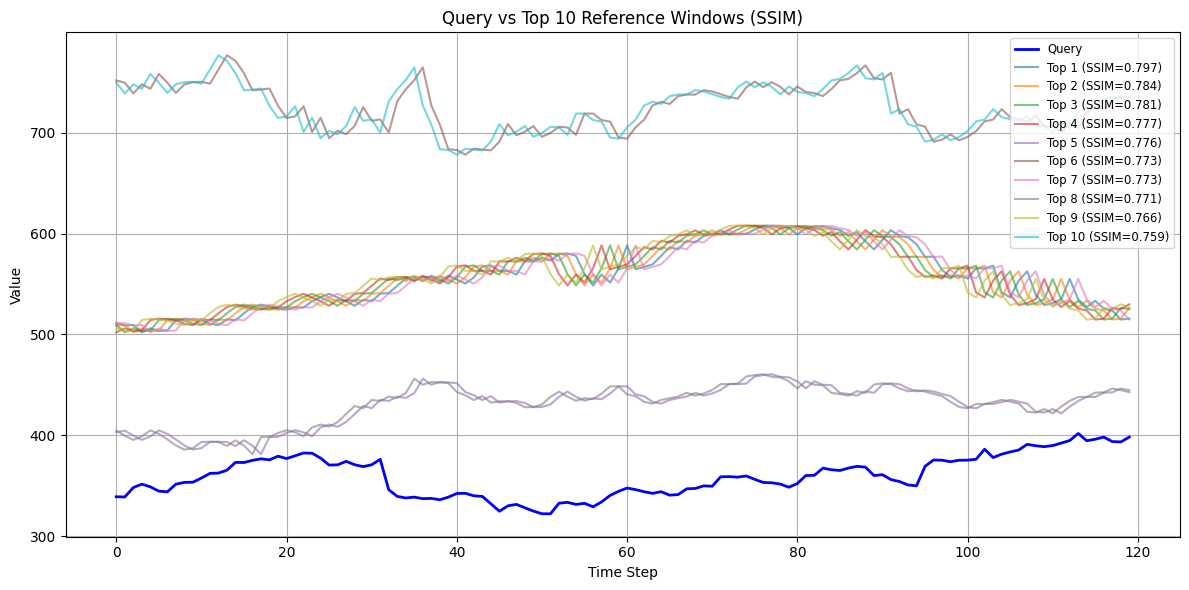

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# query window
query_window = window_list[0].flatten()
plt.plot(query_window, label='Query', linewidth=2, color='blue')

# top 10 reference windows
for i, w in enumerate(top_windows):
    plt.plot(w.flatten(), label=f"Top {i+1} (SSIM={top_scores[i].item():.3f})", alpha=0.6)
    
plt.title("Query vs Top 10 Reference Windows (SSIM)")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend(loc='upper right', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()



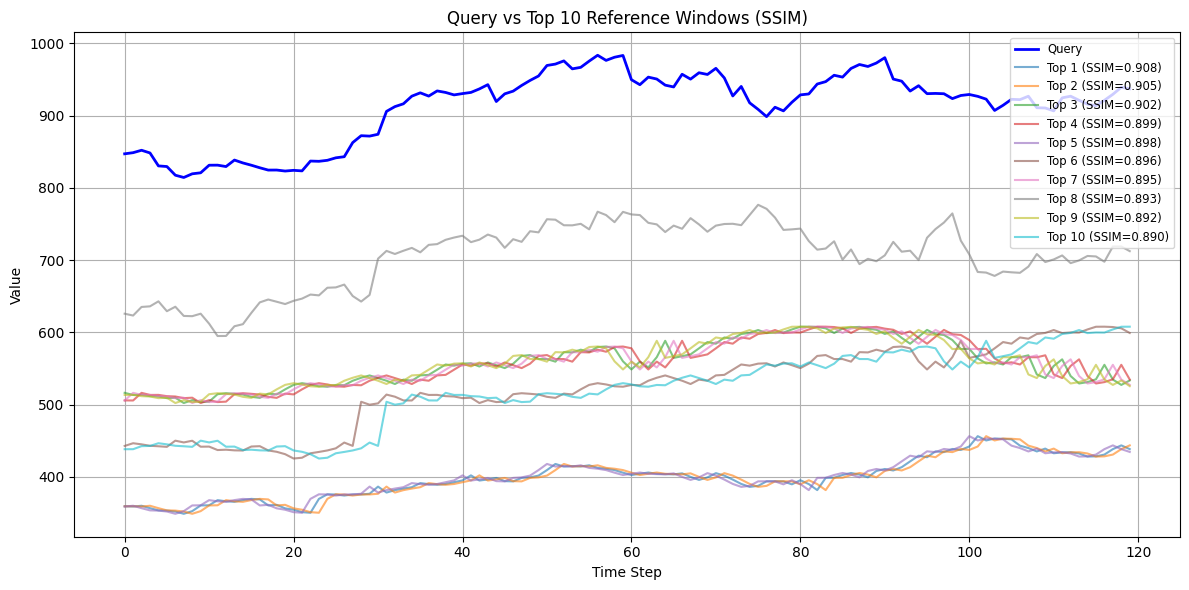

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# query window
query_window = window_list[-1].flatten()
plt.plot(query_window, label='Query', linewidth=2, color='blue')

# top 10 reference windows
for i, w in enumerate(top_windows):
    plt.plot(w.flatten(), label=f"Top {i+1} (SSIM={top_scores[i].item():.3f})", alpha=0.6)
    
plt.title("Query vs Top 10 Reference Windows (SSIM)")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend(loc='upper right', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()



In [3]:
import torch
import torch.nn as nn
model = torch.hub.load('pytorch/vision:v0.10.0', 'mobilenet_v2', pretrained=True)
model.eval()
first_layers = nn.Sequential(*list(model.features.children())[:4])

Using cache found in /home/user11/.cache/torch/hub/pytorch_vision_v0.10.0


In [4]:
print(first_layers)

Sequential(
  (0): ConvBNActivation(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU6(inplace=True)
  )
  (1): InvertedResidual(
    (conv): Sequential(
      (0): ConvBNActivation(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (2): InvertedResidual(
    (conv): Sequential(
      (0): ConvBNActivation(
        (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(in

In [7]:
x = torch.rand(1, 3, 20, 20)

In [8]:
x1 = first_layers(x)

In [9]:
print(x1.shape)

torch.Size([1, 24, 5, 5])
